In [1]:
import pandas as pd

In [2]:
# Loading the dataset
df = pd.read_csv("Mental_Health_Dataset.csv")  # adjust name if different

In [3]:
# Preview
print("Shape:", df.shape)
df.head()

Shape: (1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,27-08-2014 11:29,37,Female,United States,IL,NaN,No,Yes,Often,Jun-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,27-08-2014 11:29,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,27-08-2014 11:29,32,Male,Canada,NaN,NaN,No,No,Rarely,Jun-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,27-08-2014 11:29,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,27-08-2014 11:30,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [4]:
# Null value check
df.isnull().sum().sort_values(ascending=False)

comments                     1095
state                         515
work_interfere                264
self_employed                  18
seek_help                       0
obs_consequence                 0
mental_vs_physical              0
phys_health_interview           0
mental_health_interview         0
supervisor                      0
coworkers                       0
phys_health_consequence         0
mental_health_consequence       0
leave                           0
anonymity                       0
Timestamp                       0
wellness_program                0
Age                             0
benefits                        0
tech_company                    0
remote_work                     0
no_employees                    0
treatment                       0
family_history                  0
Country                         0
Gender                          0
care_options                    0
dtype: int64

In [5]:
# Dropping unnecessary columns
df.drop(['Timestamp', 'comments'], axis=1, inplace=True)

In [6]:
# Clean Age
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]

In [7]:
# Clean Gender
def clean_gender(g):
    g = str(g).lower()
    if "male" in g:
        return "Male"
    elif "female" in g:
        return "Female"
    else:
        return "Other"

df['Gender'] = df['Gender'].apply(clean_gender)

In [8]:
# Filling the missing values
df.fillna({'self_employed': 'Unknown'}, inplace=True)
df.fillna({'work_interfere': 'Unknown'}, inplace=True)
df.fillna({'state': 'Unknown'}, inplace=True)

In [9]:
# Check cleaned shape and preview
print("Cleaned Shape:", df.shape)
df.head()

Cleaned Shape: (1250, 25)


,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Male,United States,IL,Unknown,No,Yes,Often,Jun-25,No,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Other,United States,IN,Unknown,No,No,Rarely,More than 1000,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,Unknown,Unknown,No,No,Rarely,Jun-25,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,Unknown,Unknown,Yes,Yes,Often,26-100,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,TX,Unknown,No,No,Never,100-500,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


In [10]:
# Encoding the target column - 'Treatment'
df['treatment'] = df['treatment'].map({'Yes': 1, 'No': 0})

In [11]:
# one hot encoding 
X = df.drop('treatment', axis=1)
y = df['treatment']

# One-hot encoding all categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

In [12]:
# splitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [13]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 89  26]
 [ 15 120]]
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       115
           1       0.82      0.89      0.85       135

    accuracy                           0.84       250
   macro avg       0.84      0.83      0.83       250
weighted avg       0.84      0.84      0.84       250



In [14]:
# Model Finalisation and Cross - Validation 
from sklearn.model_selection import cross_val_score

In [15]:
scores = cross_val_score(model, X_encoded, y, cv=5)
print("Cross-val accuracy:", scores.mean())

Cross-val accuracy: 0.8215999999999999


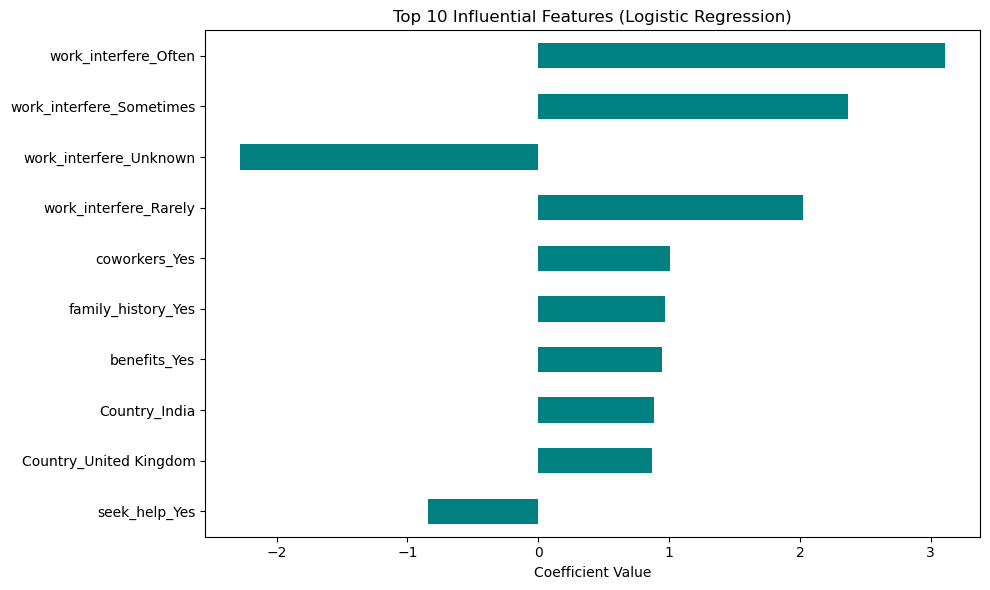

In [16]:
# Feature Importance / Interpretability
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Creating a series with encoded feature names
coefficients = pd.Series(model.coef_[0], index=X_encoded.columns)

# Sorting it by absolute value for most influential features
coefficients = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

# Plotting top 10
plt.figure(figsize=(10, 6))
coefficients.head(10).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title("Top 10 Influential Features (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

In [19]:
import re
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd

# Converting to numpy arrays
X_train_np = X_train.values
X_test_np = X_test.values

# Initializing Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=X_train.columns.tolist(),
    class_names=['No Treatment', 'Treatment'],
    mode='classification'
)

# Initializing feature importance dict
feature_importance = {feature: [] for feature in X_train.columns.tolist()}

# Looping through test instances
for i in range(len(X_test)):
    exp = explainer.explain_instance(X_test_np[i], model.predict_proba, num_features=len(X_train.columns))
    
    # Loop through feature contributions
    for feature_full, importance in exp.as_list():
        # Extract base feature name before condition
        base_feature = re.split(r' [<>=]', feature_full)[0].strip()

        # Ensure feature exists in our dict
        if base_feature in feature_importance:
            feature_importance[base_feature].append(importance)

# Calculate mean importance
mean_importance = {feature: np.mean(scores) if scores else 0 for feature, scores in feature_importance.items()}

# Sorting by absolute importance
sorted_features = sorted(mean_importance.items(), key=lambda x: abs(x[1]), reverse=True)

# Display top 10 important features
print("\n🔝 Top 10 Important Features (LIME-based Aggregation):")
for feature, score in sorted_features[:10]:
    print(f"{feature}: {score:.4f}")


C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X d


🔝 Top 10 Important Features (LIME-based Aggregation):
work_interfere_Sometimes: -0.3588
work_interfere_Often: -0.3262
work_interfere_Rarely: -0.2018
work_interfere_Unknown: 0.1887
family_history_Yes: -0.1353
benefits_Yes: -0.1325
Country_India: -0.1198
care_options_Yes: -0.1076
state_MD: 0.0998
state_TN: 0.0908


C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import os
import pickle

# Saving the trained model
with open('model/trained_model.pkl', 'wb') as f:
    pickle.dump(model, f)